In [1]:
# 4. Write a Python program to compute and visualize covariance and correlation matrices for multivariate datasets.  
# 5. Write a Python program to analyze univariate and multivariate normal distributions.  
# 6. Write a Python program to perform hypothesis testing using statistical libraries such as SciPy.  
# 7. Write a Python program to compute confidence intervals for population parameters.  
# 8. Write a Python program to manipulate and transform datasets using the Pandas library.  
# 9. Write a Python program to visualize data using Matplotlib and Seaborn.  
# 10. Write a Python program to create bar charts, histograms, pie charts, box plots, scatter plots, and heatmaps.  

In [2]:
# Setup: load the Titanic dataset used for all questions below
import pandas as pd # pip install pandas
import numpy as np # pip install numpy
import matplotlib.pyplot as plt # pip install matplotlib
import seaborn as sns # pip install seaborn
from scipy import stats # pip install scipy

df = pd.read_csv('Datasets/titanic/train.csv')
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Covariance Matrix:
           Survived     Pclass         Age     SibSp     Parch         Fare
Survived  0.241533  -0.148165   -0.551296 -0.007932  0.039133     6.974923
Pclass   -0.148165   0.702663   -4.496004  0.052412  0.018370   -24.583138
Age      -0.551296  -4.496004  211.019125 -4.163334 -2.344191    73.849030
SibSp    -0.007932   0.052412   -4.163334  0.864497  0.304513     6.806212
Parch     0.039133   0.018370   -2.344191  0.304513  0.728103     9.262176
Fare      6.974923 -24.583138   73.849030  6.806212  9.262176  2800.413100

Correlation Matrix:
           Survived    Pclass       Age     SibSp     Parch      Fare
Survived  1.000000 -0.359653 -0.077221 -0.017358  0.093317  0.268189
Pclass   -0.359653  1.000000 -0.369226  0.067247  0.025683 -0.554182
Age      -0.077221 -0.369226  1.000000 -0.308247 -0.189119  0.096067
SibSp    -0.017358  0.067247 -0.308247  1.000000  0.383820  0.138329
Parch     0.093317  0.025683 -0.189119  0.383820  1.000000  0.205119
Fare      0.268189 

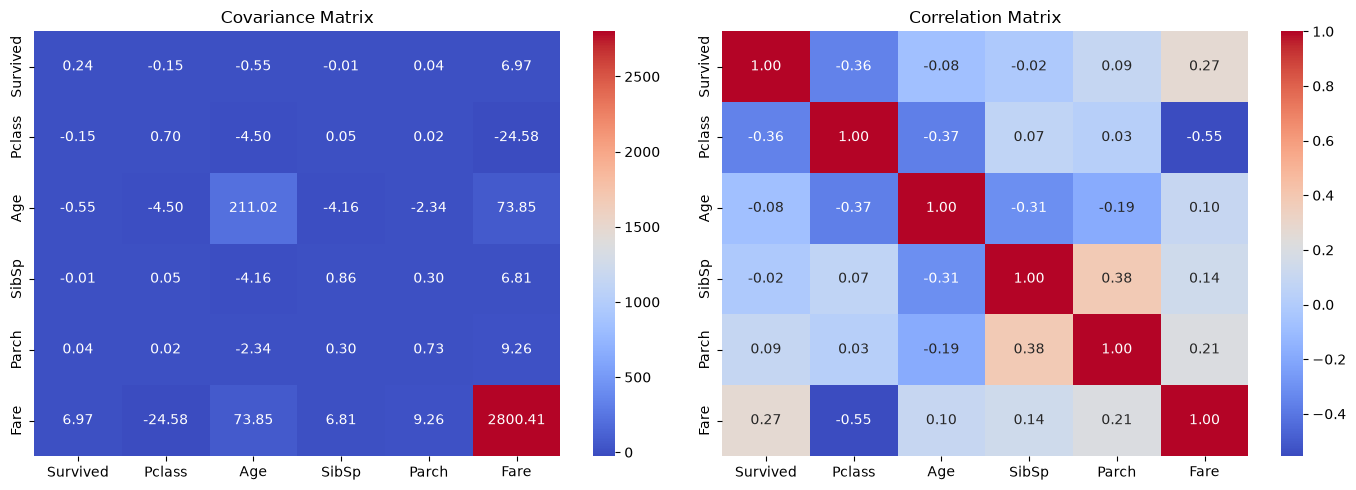

In [3]:
# 4. Compute and visualize covariance and correlation matrices for multivariate datasets
numeric_df = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].dropna()

cov_matrix = numeric_df.cov()
corr_matrix = numeric_df.corr()

print("Covariance Matrix:\n", cov_matrix)
print("\nCorrelation Matrix:\n", corr_matrix)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cov_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0])
axes[0].set_title('Covariance Matrix')
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1])
axes[1].set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

# Notes
# 1. Covariance shows the direction of the linear relationship between two variables but its magnitude is scale-dependent.
# 2. Correlation rescales covariance to a fixed range of -1 to 1, making relationships comparable across variable pairs.
# 3. Fare and Pclass are notably negatively correlated: lower Pclass numbers (1st class) paid higher fares.


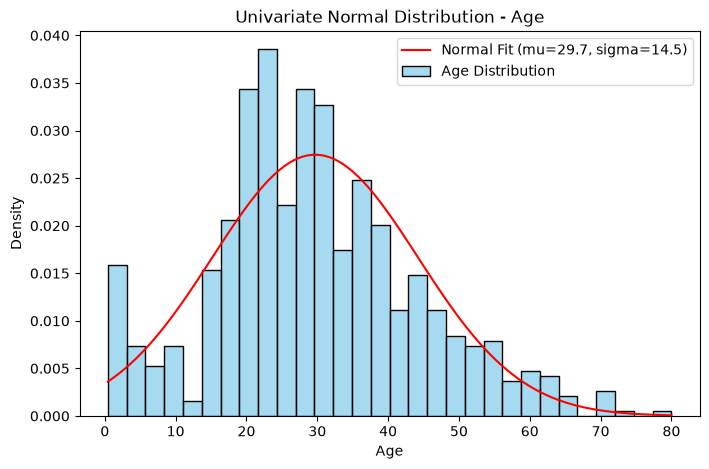

Shapiro-Wilk Test: statistic=0.9815, p-value=0.0000
Not normally distributed


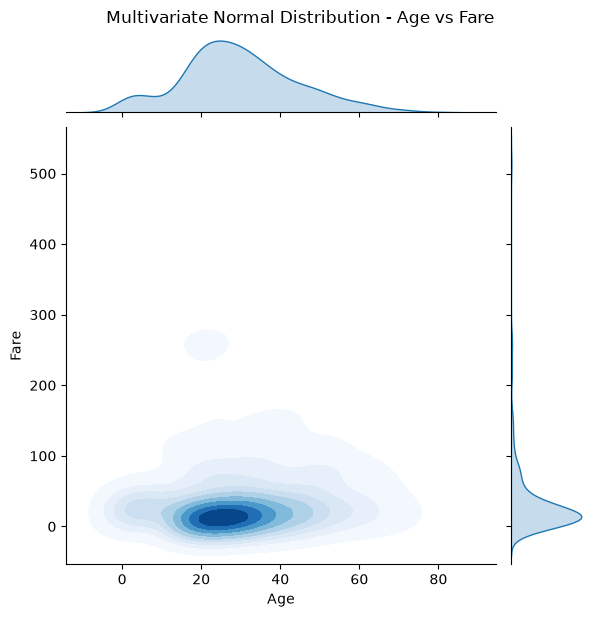

In [4]:
# 5. Analyze univariate and multivariate normal distributions
age = df['Age'].dropna()

mu, sigma = age.mean(), age.std()
x = np.linspace(age.min(), age.max(), 100)
pdf = stats.norm.pdf(x, mu, sigma)

plt.figure(figsize=(8, 5))
sns.histplot(age, stat='density', bins=30, color='skyblue', label='Age Distribution')
plt.plot(x, pdf, 'r-', label=f'Normal Fit (mu={mu:.1f}, sigma={sigma:.1f})')
plt.title('Univariate Normal Distribution - Age')
plt.legend()
plt.show()

stat, p_value = stats.shapiro(age)
print(f"Shapiro-Wilk Test: statistic={stat:.4f}, p-value={p_value:.4f}")
print("Normally distributed" if p_value > 0.05 else "Not normally distributed")

# Multivariate normal distribution - Age and Fare jointly
bivariate = df[['Age', 'Fare']].dropna()
sns.jointplot(data=bivariate, x='Age', y='Fare', kind='kde', fill=True, cmap='Blues')
plt.suptitle('Multivariate Normal Distribution - Age vs Fare', y=1.02)
plt.show()

# Notes
# 1. The Shapiro-Wilk test checks whether a single variable (Age) follows a normal distribution; a p-value <= 0.05 rejects normality.
# 2. Titanic's Age data is right-skewed and generally fails the normality test despite visually resembling a bell curve.
# 3. The joint KDE plot approximates a bivariate normal by showing the density contours of Age and Fare together.


In [5]:
# 6. Perform hypothesis testing using statistical libraries such as SciPy
survived_age = df[df['Survived'] == 1]['Age'].dropna()
died_age = df[df['Survived'] == 0]['Age'].dropna()

t_stat, p_value = stats.ttest_ind(survived_age, died_age, equal_var=False)
print(f"Independent t-test (Age: Survived vs Died): t-statistic={t_stat:.4f}, p-value={p_value:.4f}")
alpha = 0.05
if p_value < alpha:
    print("Reject H0: There is a significant difference in age between survivors and non-survivors.")
else:
    print("Fail to reject H0: No significant difference in age between survivors and non-survivors.")

# Chi-square test of independence - Sex vs Survived
contingency = pd.crosstab(df['Sex'], df['Survived'])
chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi-square test (Sex vs Survived): chi2={chi2:.4f}, p-value={p_chi2:.6f}")
if p_chi2 < alpha:
    print("Reject H0: Survival is dependent on sex.")
else:
    print("Fail to reject H0: Survival is independent of sex.")

# Notes
# 1. The independent t-test compares the mean Age of two groups (survivors vs non-survivors) to check if the difference is statistically significant.
# 2. equal_var=False runs Welch's t-test, which does not assume equal variances between the two groups.
# 3. The chi-square test checks whether two categorical variables (Sex and Survived) are statistically independent; Titanic data strongly rejects independence.


Independent t-test (Age: Survived vs Died): t-statistic=-2.0460, p-value=0.0412
Reject H0: There is a significant difference in age between survivors and non-survivors.

Chi-square test (Sex vs Survived): chi2=260.7170, p-value=0.000000
Reject H0: Survival is dependent on sex.


In [6]:
# 7. Compute confidence intervals for population parameters
fare = df['Fare'].dropna()
n = len(fare)
mean_fare = fare.mean()
sem_fare = stats.sem(fare)

ci_95_fare = stats.t.interval(0.95, df=n - 1, loc=mean_fare, scale=sem_fare)
print(f"Mean Fare: {mean_fare:.2f}")
print(f"95% Confidence Interval for Mean Fare: ({ci_95_fare[0]:.2f}, {ci_95_fare[1]:.2f})")

# Confidence interval for the proportion of survivors
p_hat = df['Survived'].mean()
n_total = len(df)
se_p = np.sqrt(p_hat * (1 - p_hat) / n_total)
z = stats.norm.ppf(0.975)
ci_prop = (p_hat - z * se_p, p_hat + z * se_p)
print(f"\nSurvival Proportion: {p_hat:.4f}")
print(f"95% Confidence Interval for Survival Proportion: ({ci_prop[0]:.4f}, {ci_prop[1]:.4f})")

# Notes
# 1. A confidence interval gives a range in which the true population parameter (mean or proportion) is likely to fall, given a confidence level.
# 2. The t-distribution is used for the mean Fare CI since the population standard deviation is unknown and is estimated from the sample.
# 3. The normal approximation (z-score) is used for the survival proportion CI since the sample size is large enough for the Central Limit Theorem to apply.


Mean Fare: 32.20
95% Confidence Interval for Mean Fare: (28.94, 35.47)

Survival Proportion: 0.3838
95% Confidence Interval for Survival Proportion: (0.3519, 0.4158)


In [7]:
# 8. Manipulate and transform datasets using the Pandas library
df_clean = df.copy()

df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])
df_clean.drop(columns=['Cabin'], inplace=True)

df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1
df_clean['AgeGroup'] = pd.cut(df_clean['Age'], bins=[0, 12, 18, 35, 60, 100],
                               labels=['Child', 'Teen', 'Adult', 'Middle-aged', 'Senior'])

survival_by_class = df_clean.groupby('Pclass')['Survived'].mean()
survival_by_agegroup = df_clean.groupby('AgeGroup', observed=True)['Survived'].mean()

print("Survival Rate by Class:\n", survival_by_class)
print("\nSurvival Rate by Age Group:\n", survival_by_agegroup)
df_clean.head()

# Notes
# 1. Missing Age values are imputed with the median (robust to outliers) and missing Embarked values with the mode (most frequent port).
# 2. Cabin is dropped since the majority of its values are missing, making it unreliable for analysis.
# 3. FamilySize and AgeGroup are engineered features that transform raw columns into more analysis-friendly categories.
# 4. groupby() aggregates survival rate across categories, revealing that higher class and younger age groups had better survival odds.


Survival Rate by Class:
 Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Survival Rate by Age Group:
 AgeGroup
Child          0.579710
Teen           0.428571
Adult          0.353271
Middle-aged    0.400000
Senior         0.227273
Name: Survived, dtype: float64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,Middle-aged
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,Adult


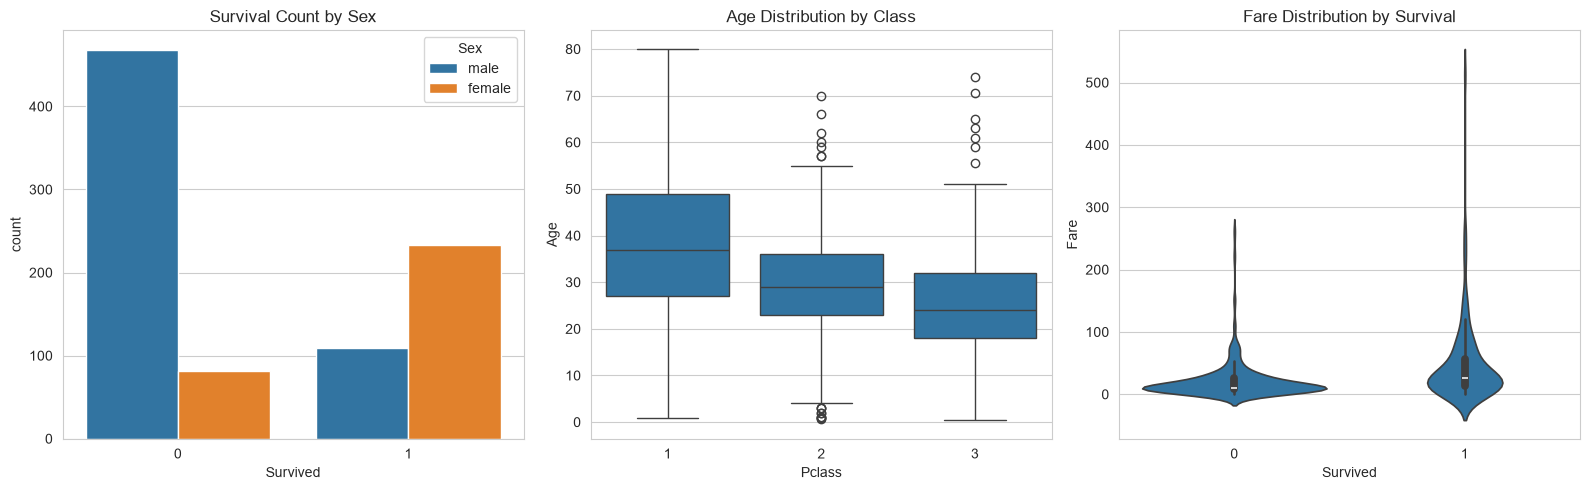

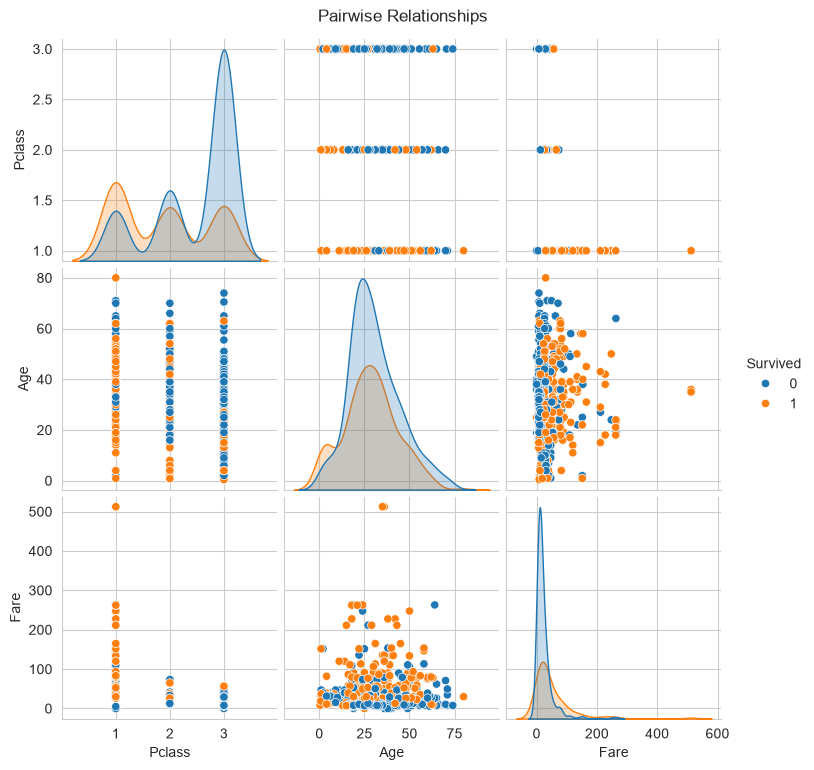

In [8]:
# 9. Visualize data using Matplotlib and Seaborn
sns.set_style('whitegrid')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.countplot(data=df, x='Survived', hue='Sex', ax=axes[0])
axes[0].set_title('Survival Count by Sex')

sns.boxplot(data=df, x='Pclass', y='Age', ax=axes[1])
axes[1].set_title('Age Distribution by Class')

sns.violinplot(data=df, x='Survived', y='Fare', ax=axes[2])
axes[2].set_title('Fare Distribution by Survival')

plt.tight_layout()
plt.show()

sns.pairplot(df[['Survived', 'Pclass', 'Age', 'Fare']].dropna(), hue='Survived')
plt.suptitle('Pairwise Relationships', y=1.02)
plt.show()

# Notes
# 1. Matplotlib provides the low-level figure/axes control, while Seaborn builds statistical plots on top of it with less code.
# 2. countplot, boxplot, and violinplot each reveal a different facet of the data: category counts, spread with outliers, and full distribution shape.
# 3. pairplot visualizes pairwise relationships between multiple numeric variables at once, split by the Survived category via hue.


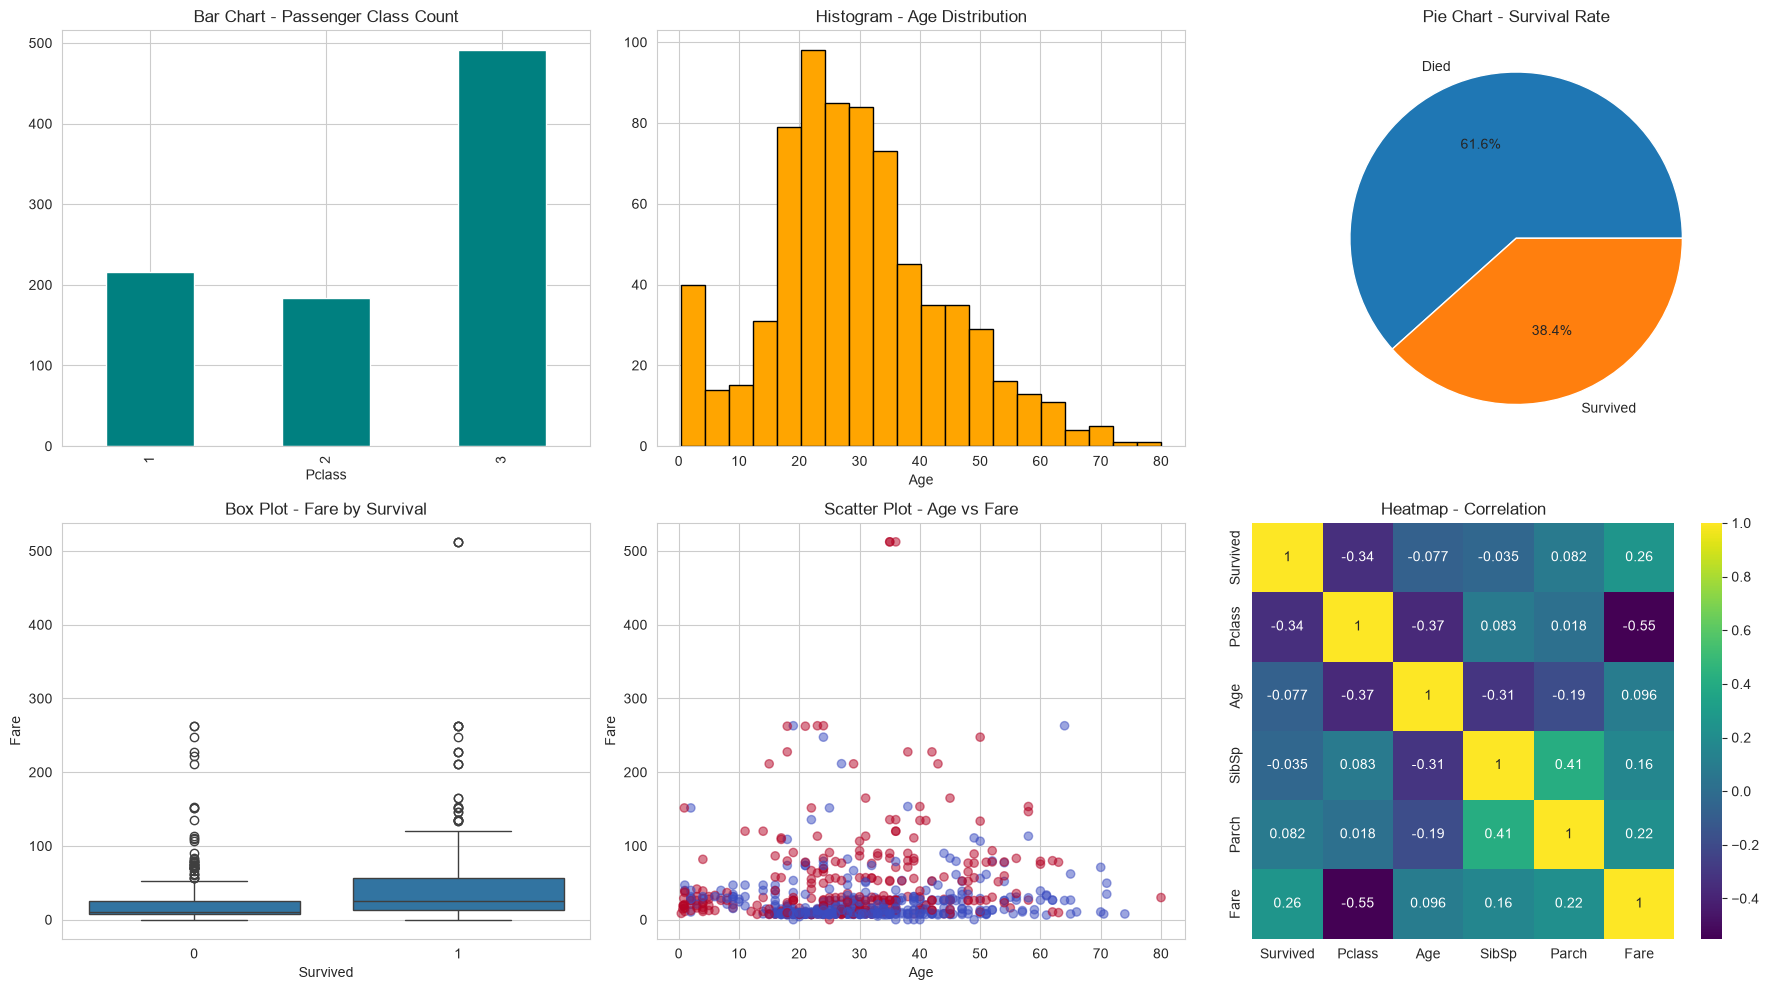

In [9]:
# 10. Create bar charts, histograms, pie charts, box plots, scatter plots, and heatmaps
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Bar chart
df['Pclass'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 0], color='teal')
axes[0, 0].set_title('Bar Chart - Passenger Class Count')
axes[0, 0].set_xlabel('Pclass')

# Histogram
axes[0, 1].hist(df['Age'].dropna(), bins=20, color='orange', edgecolor='black')
axes[0, 1].set_title('Histogram - Age Distribution')
axes[0, 1].set_xlabel('Age')

# Pie chart
df['Survived'].value_counts().plot(kind='pie', autopct='%1.1f%%', labels=['Died', 'Survived'], ax=axes[0, 2])
axes[0, 2].set_title('Pie Chart - Survival Rate')
axes[0, 2].set_ylabel('')

# Box plot
sns.boxplot(data=df, x='Survived', y='Fare', ax=axes[1, 0])
axes[1, 0].set_title('Box Plot - Fare by Survival')

# Scatter plot
scatter = axes[1, 1].scatter(df['Age'], df['Fare'], alpha=0.5, c=df['Survived'], cmap='coolwarm')
axes[1, 1].set_title('Scatter Plot - Age vs Fare')
axes[1, 1].set_xlabel('Age')
axes[1, 1].set_ylabel('Fare')

# Heatmap
sns.heatmap(df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr(),
            annot=True, cmap='viridis', ax=axes[1, 2])
axes[1, 2].set_title('Heatmap - Correlation')

plt.tight_layout()
plt.show()

# Notes
# 1. Bar charts compare counts across discrete categories (Pclass), while histograms show the distribution of a continuous variable (Age).
# 2. Pie charts communicate proportions of a whole (survival rate) but work best with few categories.
# 3. Box plots summarize distribution spread and outliers per group; scatter plots reveal relationships between two continuous variables.
# 4. The heatmap visualizes the correlation matrix, making it easy to spot the strongest linear relationships at a glance.
